<b>QUINTA LISTA DE EXERCÍCIOS - REGRESSÃO</b>

<b>QUESTÃO 1</b> - Regressão Linear Simples (Conceitual)<br>
Explique o objetivo da regressão linear simples. Descreva o significado dos parâmetros α (intercepto) e β (inclinação) na equação: <br>

y = α + βx + ε

O objetivo da regressão linear simples é prever um valor númerico(e não classificações) de acordo com outro valor, tentando estabelecer uma relação linear entre eles. Na equação da regressão linear, o β indica quanto o valor de y(valor a ser previsto) muda conforme a mudança da variável x(note que (dy/dx)=β). Já o α representa o valor inicial do modelo(quando x = 0), servindo para ajudar o modelo a ajustar-se melhor aos dados

<b>QUESTÃO 2</b> - Coeficiente de Correlação de Pearson<br>
Explique o que representa o coeficiente de correlação de Pearson (ρ). Interprete os seguintes valores:<br>
• ρ = 0.85<br>
• ρ = −0.65<br>
• ρ = 0.10

O coeficiente de correlação de Pearson mede o quanto 2 variáveis se influenciam e a direção dessa influência(direta ou inversa). <br>
ρ = 0.85 -> Indica que as duas variáveis possuem uma correlação forte e positiva(se uma aumenta a outra também aumenta)<br>
ρ = -0.65 -> Indica que as duas variáveis possuem uma correlação moderada e negativa(se uma variável aumenta, a outra diminui)<br>
p = 0.10 -> Indica uma relação muito fraca entre as duas variáveis, ou seja, elas se influenciam muito pouco(indicando independência)

<b>QUESTÃO 3 </b>- Implementação de Regressão Linear<br>
Utilizando o dataset fetch_california_housing do scikit-learn:<br>
• Carregue os dados;<br>
• Separe em treino e teste;<br>
• Treine um modelo de regressão linear;<br>
• Apresente os coeficientes do modelo.

Carregando os dados

In [113]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

dataset = fetch_california_housing()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
target = dataset.target_names[0]
features = dataset.feature_names
feature_simples = "HouseAge"
df[target] = dataset.target 
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Normalizando os dados:

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,3.422


Separando os dados em treino e teste:

In [115]:
from sklearn.model_selection import train_test_split
import numpy as np

df_treino, df_teste = train_test_split(df, shuffle=True, train_size=0.75, random_state=42)

X_treino = df_treino[features]
y_treino = df_treino[target]

X_teste = df_teste[features]
y_teste = df_teste[target]

Treinando o modelo de regressão linear(simples)

In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
#Treinando apenas com base na idade do imóvel
model.fit(X_treino[[feature_simples]], y_treino)

pred_teste_linear = model.predict(X_teste[[feature_simples]])
pred_treino_linear = model.predict(X_treino[[feature_simples]])

In [117]:
print(f"Coeficientes do modelo: {model.coef_}")
print(f"Bias do modelo: {model.intercept_}")

Coeficientes do modelo: [0.11907119]
Bias do modelo: 2.070760401904705


<b>QUESTÃO 4</b> - Cálculo do Erro (R2)<br>
Explique o significado do coeficiente de determinação R2<br>

. Em seguida:<br>
• Calcule o R2 do modelo da questão anterior;<br>
• Interprete o resultado obtido.

In [118]:
from sklearn.metrics import r2_score

r2_teste_linear = r2_score(y_true=y_teste, y_pred=pred_teste_linear)
r2_treino_linear = r2_score(y_true=y_treino, y_pred=pred_treino_linear)
print(F"R2 do modelo linear no treino: {r2_treino_linear}")
print(f"R2 do modelo linear no teste: {r2_teste_linear}")

R2 do modelo linear no treino: 0.010669028916821532
R2 do modelo linear no teste: 0.01256309520256571


O R2 baixo indica que o modelo teve um péssimo resultado em prever o target apenas com a idade do imóvel.

<b>QUESTÃO 5</b> - Visualização dos Dados<br>
Escolha uma variável independente do dataset e:<br>
• Gere um scatter plot entre esta variável e o target;<br>
• Plote a reta de regressão ajustada.

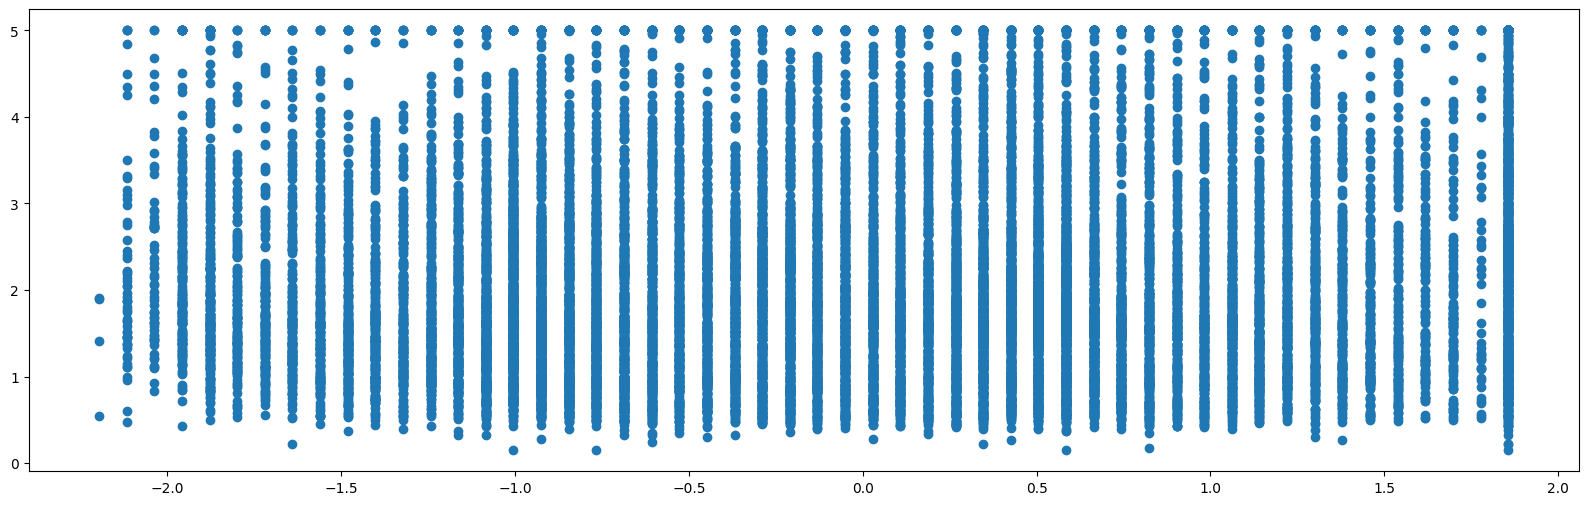

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))
plt.scatter(df[feature_simples], df[target])
plt.show()

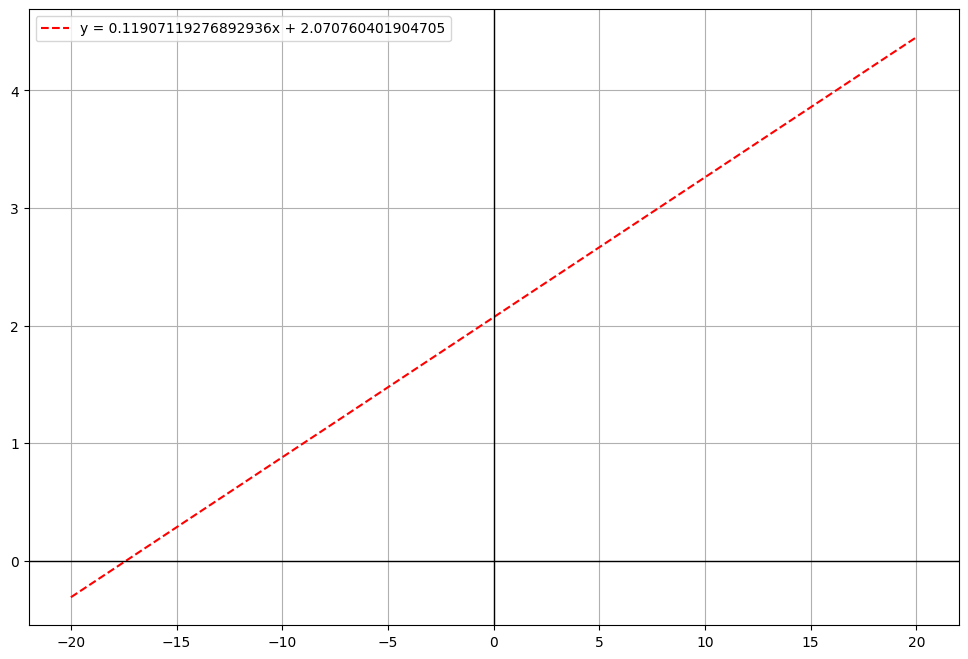

In [120]:
import numpy as np

x = np.linspace(-20, 20, 10000) 
a = model.coef_[0]
b = model.intercept_
y = a*x + b

plt.figure(figsize=(12,8))
plt.plot(x, y, label=f'y = {a}x + {b}', color='red', linestyle='--')
plt.axhline(0, color='black',linewidth=1) 
plt.axvline(0, color='black',linewidth=1)
plt.grid(True)
plt.legend()
plt.show()


<b>QUESTÃO 6</b> - Regressão Polinomial<br>
Implemente uma regressão polinomial de grau 2 utilizando o mesmo dataset:<br>
• Utilize PolynomialFeatures;<br>
• Treine o modelo;<br>
• Compare com a regressão linear simples.

In [121]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly.fit(X_treino[[feature_simples]], y_treino)

pred_teste_poly = poly.predict(X_teste[[feature_simples]])
pred_treino_poly = poly.predict(X_treino[[feature_simples]])
r2_teste_poly = r2_score(y_true=y_teste, y_pred=pred_teste_poly)
r2_treino_poly = r2_score(y_true=y_treino, y_pred=pred_treino_poly)
print(f"R2 do modelo polinomial no treino: {r2_treino_poly}")
print(f"R2 do modelo polinomial no teste: {r2_teste_poly}")

R2 do modelo polinomial no treino: 0.017729384815230675
R2 do modelo polinomial no teste: 0.013174024454408184


<b>QUESTÃO 7</b> - Comparação de Modelos<br>
Compare os modelos linear e polinomial:<br>
• Qual apresentou melhor R2?<br>
• Existe evidência de overfitting?

O modelo que apresentou o melhor R2 foi o polinomial. Analisando o R2 de cada um dos modelos no treino e no teste, não há evidências de overfitting, já que os valores estão bem parecidos(com o de teste um pouco menor, o que é absolutamente normal)

<b>QUESTÃO 8</b> - Regressão Multivariada<br>
Explique o conceito de regressão multivariada. Em seguida:<br>
• Treine um modelo utilizando múltiplas variáveis do dataset;<br>
• Analise os coeficientes obtidos;<br>
• Identifique quais variáveis mais influenciam o target.

A regressão multivariada busca, assim como a regressão linear simples, prever um valor. A diferença entre elas é que a regressão linear simples utiliza apenas de uma variável para prever o valor, enquanto a regressão multivariada utiliza duas ou mais variáveis para tal.

In [122]:
mult = LinearRegression()
mult.fit(X_treino, y_treino)

pred_treino_mult = mult.predict(X_treino)
pred_teste_mult = mult.predict(X_teste)

r2_treino_mult = r2_score(y_true=y_treino, y_pred=pred_treino_mult)
r2_teste_mult = r2_score(y_true=y_teste, y_pred=pred_teste_mult)

print(f"R2 da regressão multivariada no treino: {r2_treino_mult}")
print(f"R2 da regressão multivariada no teste: {r2_teste_mult}")

R2 da regressão multivariada no treino: 0.609873031052925
R2 da regressão multivariada no teste: 0.5910509795491351


Identificando as variáveis que mais influenciam o target

In [123]:
coeficientes = list(map(float, mult.coef_))
features_mult = mult.feature_names_in_

influencias = dict(zip(features_mult, coeficientes))
influencias = dict(sorted(influencias.items(), key=lambda x: x[1]))
for key, value in influencias.items():
    print(f"{key}: {value}")

Latitude: -0.8939924464115477
Longitude: -0.868319902412397
AveRooms: -0.3086603582012678
AveOccup: -0.03575913246894007
Population: -0.0016296029153036646
HouseAge: 0.12040973211783479
AveBedrms: 0.3764994317175093
MedInc: 0.8503397310585431


Observamos que as variáveis que mais influenciam o target são:<br>
Correlação negativa: latitude e longitude<br>
Correlação positiva: medInc

<b>QUESTÃO 9</b> - Regressão KNN<br>
Utilizando o KNeighborsRegressor:<br>
• Treine modelos com diferentes valores de K (ex: 3, 5, 10);<br>
• Compare os resultados em termos de R2;<br>
• Explique o impacto do valor de K no modelo.

In [124]:
from sklearn.neighbors import KNeighborsRegressor

knn1 = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn2 = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn3 = KNeighborsRegressor(n_neighbors=10, weights="distance")

knn1.fit(X_treino, y_treino)
knn2.fit(X_treino, y_treino)
knn3.fit(X_treino, y_treino)

pred1 = knn1.predict(X_teste)
pred2 = knn2.predict(X_teste)
pred3 = knn3.predict(X_teste)

r2_knn1 = r2_score(y_true=y_teste, y_pred=pred1)
r2_knn2 = r2_score(y_true=y_teste, y_pred=pred2)
r2_knn3 = r2_score(y_true=y_teste, y_pred=pred3)

print(f"R2 do knn1(3 vizinhos): {r2_knn1}")
print(f"R2 do knn2(5 vizinhos): {r2_knn2}")
print(f"R2 do knn3(10 vizinhos): {r2_knn3}")

R2 do knn1(3 vizinhos): 0.6565727382831289
R2 do knn2(5 vizinhos): 0.6782429572726634
R2 do knn3(10 vizinhos): 0.6924225749731799


Pelo R2 de cada modelo, é possível concluir que o KNN3(k=10) obteve o melhor desempenho. Nesse experimento, notamos que aumentar o valor de K apenas melhorou o modelo, apesar disso nem sempre acontecer no KNN. 

<b>QUESTÃO 10</b> - Análise Crítica<br>
Responda:<br>
• Quando utilizar modelos paramétricos vs não-paramétricos?<br>
• Quais são as vantagens e desvantagens da regressão linear em relação ao KNN?<br>
• Em quais situações a regressão polinomial é mais adequada?

<b>Quando utilizar modelos paramétricos vs não-paramétricos?</b>

Modelos paramétricos podem ser utilizados quando é identificado um determinado padrão nos dados, utilizando o modelo correto que potencializa a previsão de acordo com esse padrão(exemplo: utilizar regressão linear se houver linearidade entre os dados). Já os modelos não-paramétricos podem ser usados quando não houver a identificação de um padrão nos dados, delegando tal responsabilidade ao modelo.

<b>Quais são as vantagens e desvantagens da regressão linear em relação ao KNN?</b>

O modelo de regressão linear pode não prever bem valores que não sigam uma relação linear, coisa que o KNN tenta contornar, buscando por similaridades nos dados. Apesar disso, o desempenho do KNN tende a ser pior que o do modelo de regressão linear(já que o processamento do KNN depende da quantidade de dados de treino) e o KNN é mais vulnerável a overfitting(modelo ficar super ajustado aos dados de treinamento).

<b>Em quais situações a regressão polinomial é mais adequada?</b>


Quando os dados não apresentam uma relação linear, podendo apresentar curvas mais ou menos acentuadas em alguns intervalos.